# Bivariate analysis of categorical variables and the chi-square test

This notebook presents a bivariate analysis of categorical variables, specifically examining the relationship between individuals' regions of origin, birth years and genders. A chi-square test is employed to determine if there is a statistically significant association between these factors over time. 

The aim is to understand how the geographical distribution of the population has changed over time and whether there is a significant over-representation of females in certain regions.


In [1]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [2]:
### Librairies déjà installées avec Python
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [3]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world region of birth

In [4]:
csv_address='da_data/da3-birthYear-gender-region.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe
2,http://www.wikidata.org/entity/Q100153910,Frank J. Blatt,1924,male,Vienna,POINT (16.3725 48.208333),http://www.wikidata.org/entity/Q1741,22,Western Europe
3,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,1953,male,Prague,POINT (14.421389 50.0875),http://www.wikidata.org/entity/Q1085,8,Eastern Europe
4,http://www.wikidata.org/entity/Q100169285,Robert M. Winglee,1958,male,Sydney,POINT (151.21 -33.867778),http://www.wikidata.org/entity/Q3130,2,Australia/New Zealand


In [5]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21445 entries, 0 to 21444
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      21445 non-null  object
 1   labelPer    21445 non-null  object
 2   birthYear   21445 non-null  int64 
 3   gender      21351 non-null  object
 4   labelPlace  21445 non-null  object
 5   geometry    21445 non-null  object
 6   uriPlace    21445 non-null  object
 7   FID         21445 non-null  int64 
 8   REGION      21445 non-null  object
dtypes: int64(2), object(7)
memory usage: 1.5+ MB


## Distribution of regions of birth

In [6]:
### Group and count
df_region = df_p.groupby('REGION').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)



                       number
REGION                       
Western Europe           5538
Eastern Europe           4548
Northern America         2795
Southern Europe          1935
Northern Europe          1687
European Russia          1665
Eastern Asia              862
Western Asia              621
Southern Asia             445
South America             337
Asiatic Russia            293
Australia/New Zealand     190
Central Asia              182
Northern Africa            95
Central America            88
Southeastern Asia          51
Southern Africa            47
Western Africa             27
Caribbean                  16
Eastern Africa             13
Middle Africa               6
Polynesia                   2
Micronesia                  2


In [7]:
### We define a function that codes and aggregates our values in order to avoid dispersion, 
# which would make them difficult to analyse.

def codeRegion(region: str):
    if ' Africa' in region:
        output='Africa'
    elif 'Russia' in region:
        output='Russia'
    elif 'Asia' in region:
        output='Asia'
    elif 'Austral' in region \
        or 'Polyn' in region \
        or 'Micron' in region:
        output='Australia/Ilands'
    elif 'Northern America' in region:
        output='America North'
    elif ' America' in region:
        output='America Central/South'
    elif 'Caribb' in region:
        output='America Central/South'
    else:
        output=region
    return output                   

In [8]:
### Test the function
# r='Southern Africa'
# r='Central Asia'
r='Asiatic Russia'
codeRegion(r)

'Russia'

In [9]:
df_p['coded_region']=df_p.REGION.apply(lambda x : codeRegion(x))

In [10]:
### Regrouper et compter
df_region = df_p.groupby('coded_region').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)



                       number
coded_region                 
Western Europe           5538
Eastern Europe           4548
America North            2795
Asia                     2161
Russia                   1958
Southern Europe          1935
Northern Europe          1687
America Central/South     441
Australia/Ilands          194
Africa                    188


In [11]:
### Add frequency

df_region['frequency'] = (100 * df_region['number'] \
                                   / df_region['number'].sum()).round(2)
df_region



,number,frequency
coded_region,,
Western Europe,5538,25.82
Eastern Europe,4548,21.21
America North,2795,13.03
Asia,2161,10.08
Russia,1958,9.13
Southern Europe,1935,9.02
Northern Europe,1687,7.87
America Central/South,441,2.06
Australia/Ilands,194,0.90


In [12]:
### Transform to one row dataframe
ljt = pd.DataFrame(df_region['frequency'].sort_values(ascending=False)).T
ljt



coded_region,Western Europe,Eastern Europe,America North,Asia,Russia,Southern Europe,Northern Europe,America Central/South,Australia/Ilands,Africa
frequency,25.82,21.21,13.03,10.08,9.13,9.02,7.87,2.06,0.9,0.88


In [13]:
### Create color palette
colors = plt.cm.tab20(range(10))
print(colors[:2], '\n', colors[-2:])

[[0.12156863 0.46666667 0.70588235 1.        ]
 [0.68235294 0.78039216 0.90980392 1.        ]] 
 [[0.58039216 0.40392157 0.74117647 1.        ]
 [0.77254902 0.69019608 0.83529412 1.        ]]


In [14]:
### Refersed list
rev_col=colors[::-1]
print(rev_col[:2], '\n', rev_col[-2:])

[[0.77254902 0.69019608 0.83529412 1.        ]
 [0.58039216 0.40392157 0.74117647 1.        ]] 
 [[0.68235294 0.78039216 0.90980392 1.        ]
 [0.12156863 0.46666667 0.70588235 1.        ]]


[]

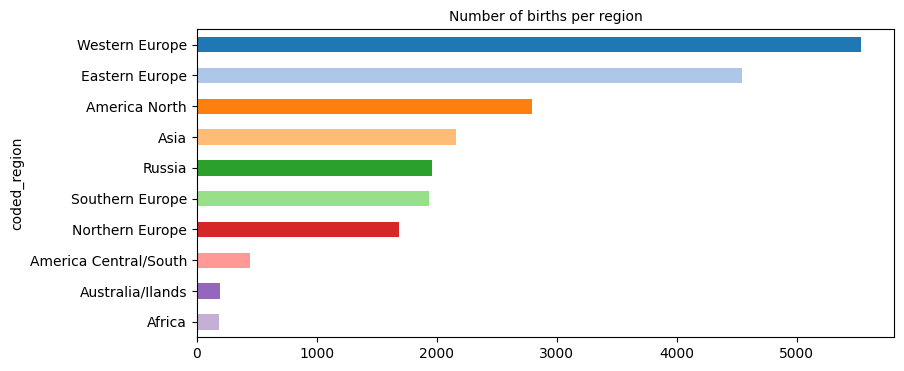

In [15]:
## Distribution of births per region
fig = df_region.number.sort_values().plot(kind='barh', figsize=(9,4), color=rev_col, width=0.5)
fig.set_title('Number of births per region', size=10)
plt.plot()

[]

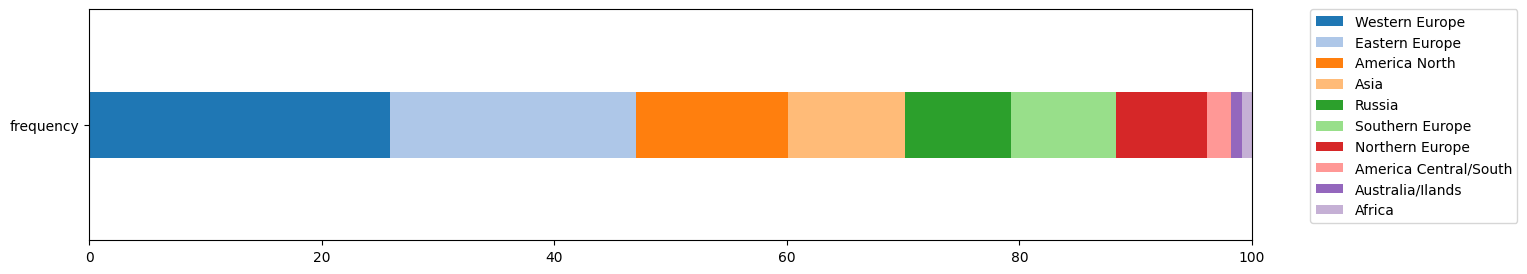

In [16]:
### Pandas plot reference
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html
## Barplots
# https://www.shanelynn.ie/bar-plots-in-python-using-pandas-dataframes/

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

### Transform birth years to periods of activity years

In [17]:
### Create imputed activity year
df_p['activityYear'] = df_p.birthYear.apply(lambda x : int(x)+45)

In [18]:
### Create list of 25 years periods

yr = df_p.activityYear

l_25 = list(range(min(yr), max(yr)+26, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1826, 1851, 1876, 1901, 1926] [1926, 1951, 1976, 2001, 2026] 8


In [19]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

df_p['per_25'] = pd.cut(df_p['activityYear'], l_25, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_p['per_25'] = df_p['per_25'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe,Western Europe,1974,1951-1975
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe,Northern Europe,1937,1926-1950
2,http://www.wikidata.org/entity/Q100153910,Frank J. Blatt,1924,male,Vienna,POINT (16.3725 48.208333),http://www.wikidata.org/entity/Q1741,22,Western Europe,Western Europe,1969,1951-1975


In [20]:
### Distribution of activities by 25 years periods
activities_per = pd.DataFrame(df_p.groupby(by='per_25').size())
activities_per.columns=['number']
print(activities_per)

           number
per_25           
1826-1850     408
1851-1875     574
1876-1900     948
1901-1925    1464
1926-1950    2311
1951-1975    4955
1976-2000    7265
2001-2025    3520


In [21]:
### Add frequency

activities_per['frequency'] = (100 * activities_per['number'] \
                                   / activities_per['number'].sum()).round(2)
activities_per


,number,frequency
per_25,,
1826-1850,408,1.90
1851-1875,574,2.68
1876-1900,948,4.42
1901-1925,1464,6.83
1926-1950,2311,10.78
1951-1975,4955,23.11
1976-2000,7265,33.88
2001-2025,3520,16.41


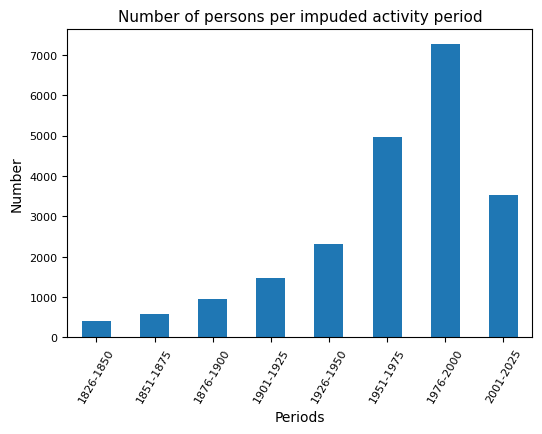

In [22]:
### Distribution by impuded active generations
ax = activities_per.number.plot(kind='bar',rot=60, fontsize=8, figsize=(6,4))
plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Number of persons per impuded activity period', size=11)
plt.show()

In [23]:
### Transform to one row dataframe
ljt = pd.DataFrame(activities_per.frequency.sort_index(ascending=True)).T
ljt



per_25,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025
frequency,1.9,2.68,4.42,6.83,10.78,23.11,33.88,16.41


In [24]:
### Map the intensity of the colours to the frequency

frequencies = activities_per.frequency.sort_index(ascending=True)

# Normalize frequencies to 0-1 range for colormap mapping
norm = mcolors.Normalize(vmin=frequencies.min(), vmax=frequencies.max())

# Create a list of colors based on the 'Blues' colormap
# Higher frequencies get darker blues
colors = [plt.cm.Blues(norm(freq)) for freq in frequencies]

[]

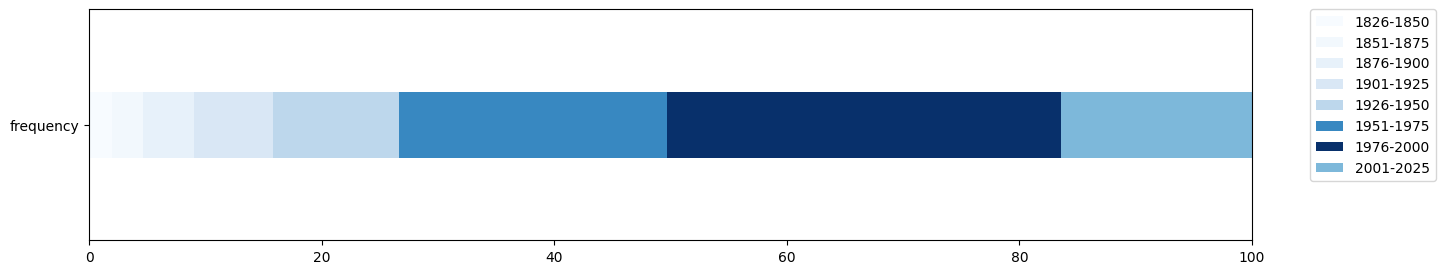

In [25]:
### Frequencies of periods. Total = 100%

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

## Bivariate analysis

* A contingency table organises data to show the frequency of two or more categorical variables arranged in rows and columns, revealing possible relationships between them.
* Frequency counts are produced by calculating how often each combination of categories occurs in the dataset.

In [26]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_region=pd.crosstab(df_p.per_25, df_p.coded_region, margins=True)
per_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_25,,,,,,,,,,,
1826-1850,0,1,17,3,0,69,90,13,52,163,408
1851-1875,0,5,48,6,0,75,98,18,62,262,574
1876-1900,3,13,87,12,4,162,145,51,94,377,948
1901-1925,3,10,205,34,12,245,164,103,149,539,1464
1926-1950,13,25,338,124,19,458,222,234,154,724,2311
1951-1975,34,79,888,507,66,1008,382,556,291,1144,4955
1976-2000,84,176,914,1019,61,1826,404,773,590,1418,7265
2001-2025,51,132,298,456,32,705,182,210,543,911,3520
All,188,441,2795,2161,194,4548,1687,1958,1935,5538,21445


In [27]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X_reg_all_period = per_vs_region.iloc[:-1, :-1 ]

In [28]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(X_reg_all_period)


In [29]:
### Expected values under independent sampling (H0 hypotheses)

## For the chi-square test the min value in each cell of the expected values should be 5

dfe = pd.DataFrame(expected).round(1)
dfe.index = X_reg_all_period.index
dfe.columns = X_reg_all_period.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1826-1850,3.6,8.4,53.2,41.1,3.7,86.5,32.1,37.3,36.8,105.4
1851-1875,5.0,11.8,74.8,57.8,5.2,121.7,45.2,52.4,51.8,148.2
1876-1900,8.3,19.5,123.6,95.5,8.6,201.0,74.6,86.6,85.5,244.8
1901-1925,12.8,30.1,190.8,147.5,13.2,310.5,115.2,133.7,132.1,378.1
1926-1950,20.3,47.5,301.2,232.9,20.9,490.1,181.8,211.0,208.5,596.8
1951-1975,43.4,101.9,645.8,499.3,44.8,1050.8,389.8,452.4,447.1,1279.6
1976-2000,63.7,149.4,946.9,732.1,65.7,1540.7,571.5,663.3,655.5,1876.1
2001-2025,30.9,72.4,458.8,354.7,31.8,746.5,276.9,321.4,317.6,909.0


In [32]:
## Degrees of freedom

print(dof, statistic)


63 2042.5766574641766


## Chi-square Test of Independence of Categorical Variables

The Chi-square test relies on a mathematical approximation that assumes the expected distribution is smooth. If the expected count in a cell is too low, the approximation breaks down, even if your actual observed data has high numbers elsewhere.

Key distinction:
* Observed Table: Your actual count data. Can contain zeros or small numbers without invalidating the test immediately.
* Expected Table: Calculated values based on row/column totals

$$ E = \frac{\text{row total} \times \text{column total}}{\text{grand total}} $$


* More about this topic in [Chi-Square Test of Independence: Definition, Formula, and Example](https://www.statology.org/chi-square-test-of-independence/)
* See the whole website: https://www.statology.org/tutorials/


### Probability distribution of Chi-square values in relation to degrees of freedom

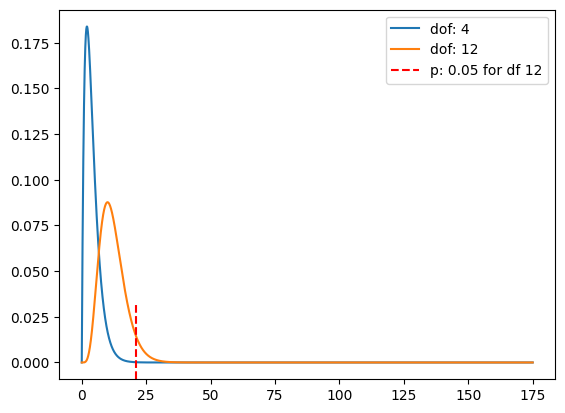

In [45]:
### Documentation ! 
## https://www.statology.org/plot-chi-square-distribution-python/
# x-axis ranges from 0 to 1750 with .001 steps
x = np.arange(0, 175, 0.001)

### plot Chi-square distribution with 4 degrees of freedom
# cf. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html
plt.plot(x, stats.chi2.pdf(x, df=4), label='dof: 4')
plt.plot(x, stats.chi2.pdf(x, df=12), label='dof: 12')

plt.axvline(x=21.026, ymax=0.2, color='red', linestyle='--', label='p: 0.05 for df 12')

plt.legend()
plt.show()

### Statistical test: rejection of the null hypothesis of independence?

The null hypothesis H0 is that the variables are independent

* critical value for 12 degrees of freedom, at the 5% level (= 0.05), Table D2 = 21.026
  * [Chi-square Distribution Table](https://www.statology.org/chi-square-distribution-table/) (Zach Bobbitt)
  * https://fr.wikipedia.org/wiki/Loi_du_%CF%87%C2%B2

* Observed chi-2 = 171.85
* P-value: 2.0017466576875573e-30 (see https://www.statology.org/chi-square-p-value-calculator/)
The chi-square value is therefore well above the critical value at a 5% error rate, so H0 (the null hypothesis of independence) can be rejected. A relationship appears between region and product sold.
We can then measure the strength of this relationship and its components, including using Cramer’s coefficient

### Caveats regarding the expected values table

This is where the "no value < 1" and "max 20% < 5" rules must be checked.

The standard rule of thumb tehrefore states:

* No cell should have an expected frequency less than 1.
* No more than 20% of the cells should have an expected frequency less than 5.

If your table violates these conditions (e.g., many cells < 5 or any cell < 1), the Chi-square approximation may be inaccurate.

In [31]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 2042.5766574641766 , dof : 63
p-value : 0.0


### Cramér's V (Cramér's phi coefficient)

* We calculate Cramér's V to measure the strength of the association between the two categorical variables.
* Interpretation of values:
  * 0.0-0.1: neglibigle;
  * 0.1-0.3: weak;
  * 0.3-0.5: moderate;
  * &gt; 0.5: strong

$$ 
V = \sqrt{\frac{\chi^2}{n \times \min(r-1, c-1)}} 
$$

* ${\chi^2}$ = 'statistic' in Python *stats* library
* n = number of individuals
* k = normalization Factor (kk):
  * Formula: k=min⁡(r−1,c−1)k (Minimum)
  * Usage: Used only in the denominator of Cramér's V to normalize the score between 0 and 1.



In [32]:
## Cramer's V with all calculation steps to demonstrate normalization

# 1. Total sample size (n)
n = per_vs_region.iloc[-1, -1]
# print(n)

# 2. Get the dimensions of the table
r, c = X_reg_all_period.shape

# 3. Calculate the correct denominator: min(rows-1, columns-1)
# Note: The returned ‘dof’ is (r-1)*(c-1); this is not directly the divisor for Cramer's rule
k = min(r - 1, c - 1)
# print(k)

# Avoid dividing by zero if the table is 1x1
if k == 0:
    cramers_v = 0
else:
    # 4. Apply the formula
    cramers_v = np.sqrt(statistic / (n * k))

print(f"Cramer's V : {cramers_v.round(5)}")

Cramer's V : 0.11665


In [33]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X_reg_all_period, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.11664795702420783


In [34]:
# 2. Calculate Adjusted Residuals
observed = X_reg_all_period
row_totals = observed.sum(axis=1).values.reshape(-1, 1)
print(row_totals)
col_totals = observed.sum(axis=0).values.reshape(1, -1)
print(col_totals)
n = observed.sum().sum()

[[ 408]
 [ 574]
 [ 948]
 [1464]
 [2311]
 [4955]
 [7265]
 [3520]]
[[ 188  441 2795 2161  194 4548 1687 1958 1935 5538]]


In [35]:
# Basic formula
residuals = (round((observed-expected)/np.sqrt(expected),2))
residuals.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1826-1850,-1.9,-2.6,-5.0,-5.9,-1.9,-1.9,10.2,-4.0,2.5,5.6
1851-1875,-2.2,-2.0,-3.1,-6.8,-2.3,-4.2,7.9,-4.8,1.4,9.3
1876-1900,-1.8,-1.5,-3.3,-8.6,-1.6,-2.8,8.2,-3.8,0.9,8.4
1901-1925,-2.8,-3.7,1.0,-9.4,-0.3,-3.7,4.6,-2.6,1.5,8.3
1926-1950,-1.6,-3.3,2.1,-7.1,-0.4,-1.4,3.0,1.6,-3.8,5.2
1951-1975,-1.4,-2.3,9.5,0.3,3.2,-1.3,-0.4,4.9,-7.4,-3.8
1976-2000,2.6,2.2,-1.1,10.6,-0.6,7.3,-7.0,4.3,-2.6,-10.6
2001-2025,3.6,7.0,-7.5,5.4,0.0,-1.5,-5.7,-6.2,12.6,0.1


In [36]:
# Formula for Adjusted Residuals
adjusted_resids = (observed - expected) / np.sqrt(expected * (1 - row_totals/n) * (1 - col_totals/n))
adjusted_resids.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1826-1850,-1.9,-2.6,-5.4,-6.3,-1.9,-2.1,10.8,-4.2,2.6,6.6
1851-1875,-2.3,-2.0,-3.4,-7.3,-2.3,-4.8,8.3,-5.1,1.5,11.0
1876-1900,-1.9,-1.5,-3.6,-9.2,-1.6,-3.2,8.7,-4.1,1.0,10.0
1901-1925,-2.9,-3.8,1.1,-10.2,-0.4,-4.3,4.9,-2.9,1.6,10.0
1926-1950,-1.7,-3.5,2.4,-8.0,-0.4,-1.7,3.3,1.8,-4.2,6.4
1951-1975,-1.6,-2.6,11.7,0.4,3.6,-1.7,-0.5,5.8,-8.8,-5.0
1976-2000,3.1,2.7,-1.4,13.8,-0.7,10.1,-9.0,5.5,-3.3,-15.1
2001-2025,4.0,7.7,-8.8,6.2,0.0,-1.9,-6.5,-7.1,14.5,0.1


In [37]:
### Using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(X_reg_all_period)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1826-1850,-1.7,-2.6,-5.4,-6.3,-1.7,-2.2,10.7,-4.2,2.6,6.5
1851-1875,-2.1,-2.0,-3.4,-7.3,-2.1,-4.9,8.3,-5.1,1.5,11.0
1876-1900,-1.9,-1.5,-3.6,-9.2,-1.6,-3.2,8.7,-4.1,1.0,10.0
1901-1925,-2.9,-3.8,1.1,-10.2,-0.4,-4.3,4.9,-2.9,1.6,10.0
1926-1950,-1.7,-3.5,2.4,-8.0,-0.5,-1.7,3.3,1.8,-4.2,6.4
1951-1975,-1.7,-2.6,11.7,0.4,3.6,-1.7,-0.5,5.8,-8.8,-5.0
1976-2000,3.1,2.7,-1.4,13.8,-0.8,10.1,-9.0,5.5,-3.3,-15.1
2001-2025,3.9,7.7,-8.8,6.2,-0.0,-1.9,-6.5,-7.1,14.5,0.1


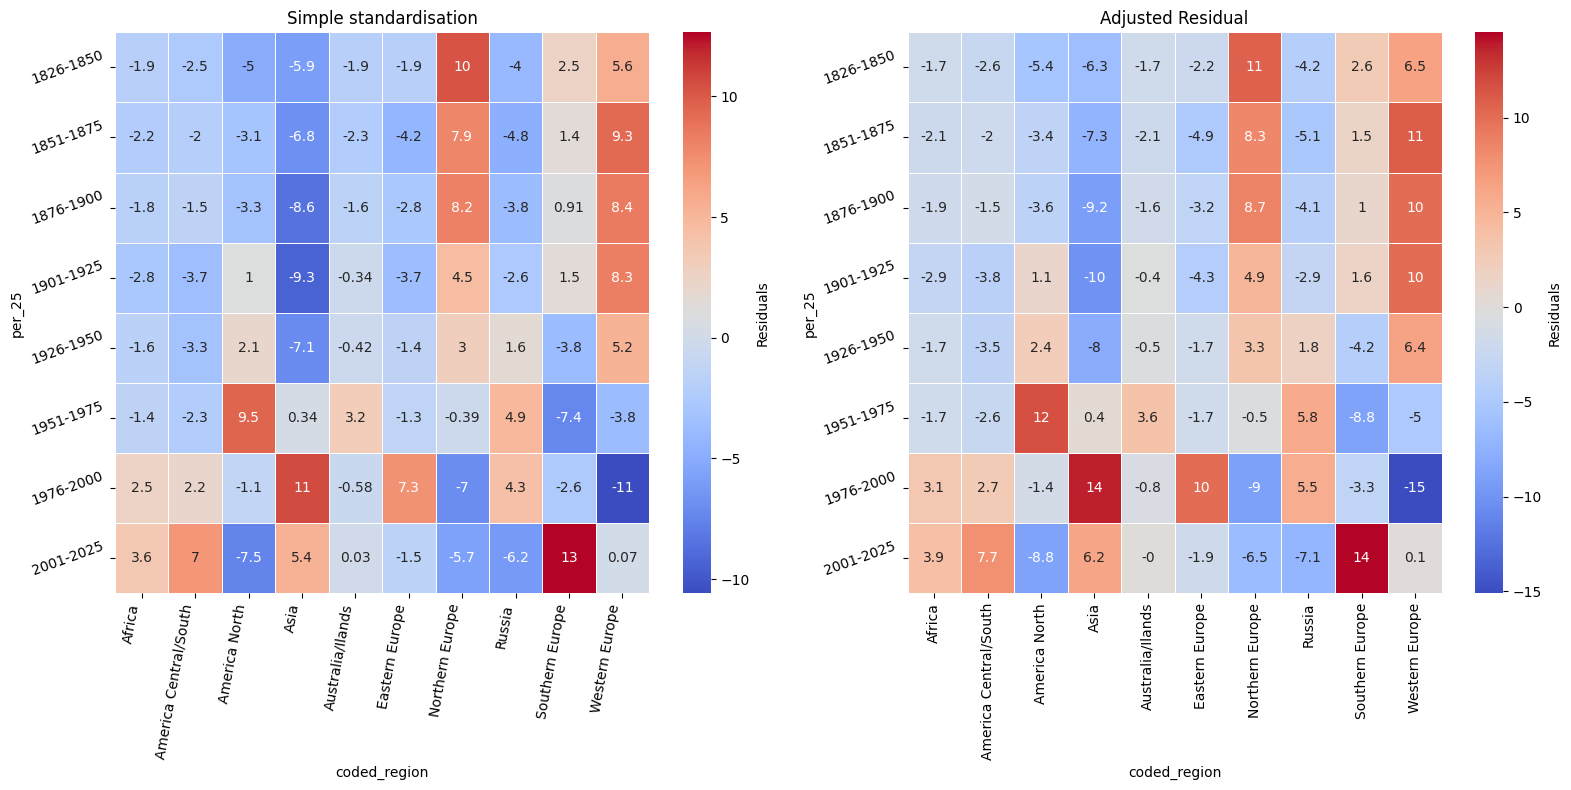

In [38]:
### Compare the two methods of calculation of residuals

# 3. Plot
fig, ax = plt.subplots(1,2,figsize=(16,8))         

# Create heatmap
sns.heatmap(
    residuals, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[0],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=80, ha='right')
ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=20, va='center')
ax[0].set_title("Simple standardisation", fontsize=12)


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[1],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
#ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=20, va='center')
ax[1].set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

Comment : 
* in this case, the differences resulting from standardization are minimal
* in both heatmaps we can easily observe the main differences from the situation of statistical independence and the evolution in time of the number of active astronomres/physicists per region

## Bivariate analysis genders

In [39]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]

In [40]:
gender_vs_region=pd.crosstab(df_pg.gender, df_pg.coded_region, margins=True)
gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
gender,,,,,,,,,,,
female,30,91,301,136,16,312,145,99,208,322,1660
male,157,349,2488,1962,176,4231,1540,1855,1722,5206,19686
All,187,440,2789,2098,192,4543,1685,1954,1930,5528,21346


In [41]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = gender_vs_region.iloc[:-1, :-1 ]

In [42]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [43]:
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
gender,,,,,,,,,,
female,14.5,34.2,216.9,163.2,14.9,353.3,131.0,152.0,150.1,429.9
male,172.5,405.8,2572.1,1934.8,177.1,4189.7,1554.0,1802.0,1779.9,5098.1


In [44]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 240.7913302914687 , dof : 9
p-value : 8.750317956356992e-47


In [52]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10620920803943215


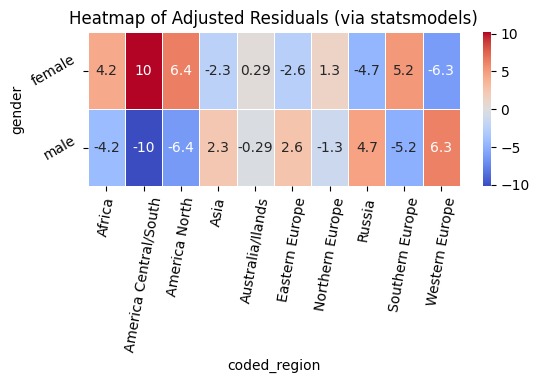

In [53]:
import statsmodels.api as sm

# 1. Create the Table object directly from your data
table = sm.stats.Table(X)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(6,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


We can observe that women are more present in some regions. The difference is statistically relevant although weak: Cramer's V = 0.1

## Bivariate analysis genders+generations vs regions

In [54]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe,Western Europe,1974,1951-1975
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe,Northern Europe,1937,1926-1950


In [55]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

In [56]:
df_pg['per_gender']= df_pg.apply(lambda x: x.per_25 +'_'+ code_gender_period(x.gender), axis=1)
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe,Western Europe,1974,1951-1975,1951-1975_m
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe,Northern Europe,1937,1926-1950,1926-1950_m


In [57]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.coded_region, margins=True)
per_gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_gender,,,,,,,,,,,
1826-1850_f,0,0,0,0,0,0,3,0,0,0,3
1826-1850_m,0,1,17,3,0,69,87,13,52,163,405
1851-1875_f,0,0,3,0,0,0,5,0,1,0,9
1851-1875_m,0,5,45,6,0,75,93,18,61,262,565
1876-1900_f,0,0,6,1,0,1,6,2,0,1,17
1876-1900_m,3,13,81,11,4,161,139,49,94,375,930
1901-1925_f,0,0,29,0,0,6,17,4,1,8,65
1901-1925_m,3,10,176,33,12,239,147,99,148,531,1398
1926-1950_f,1,3,48,4,0,23,15,17,13,54,178


In [58]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [59]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [60]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_gender,,,,,,,,,,
1826-1850_f,0.0,0.1,0.4,0.3,0.0,0.6,0.2,0.3,0.3,0.8
1826-1850_m,3.5,8.3,52.9,39.8,3.6,86.2,32.0,37.1,36.6,104.9
1851-1875_f,0.1,0.2,1.2,0.9,0.1,1.9,0.7,0.8,0.8,2.3
1851-1875_m,4.9,11.6,73.8,55.5,5.1,120.2,44.6,51.7,51.1,146.3
1876-1900_f,0.1,0.4,2.2,1.7,0.2,3.6,1.3,1.6,1.5,4.4
1876-1900_m,8.1,19.2,121.5,91.4,8.4,197.9,73.4,85.1,84.1,240.8
1901-1925_f,0.6,1.3,8.5,6.4,0.6,13.8,5.1,6.0,5.9,16.8
1901-1925_m,12.2,28.8,182.7,137.4,12.6,297.5,110.4,128.0,126.4,362.0
1926-1950_f,1.6,3.7,23.3,17.5,1.6,37.9,14.1,16.3,16.1,46.1


If we apply the rule of thumb presented above, we observe that there can be issues with the chi-square test

In [61]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 2467.0847508588377 , dof : 135
p-value : 0.0


In [62]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.11332155549667376


In [63]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),1))
# std_res.head(2)

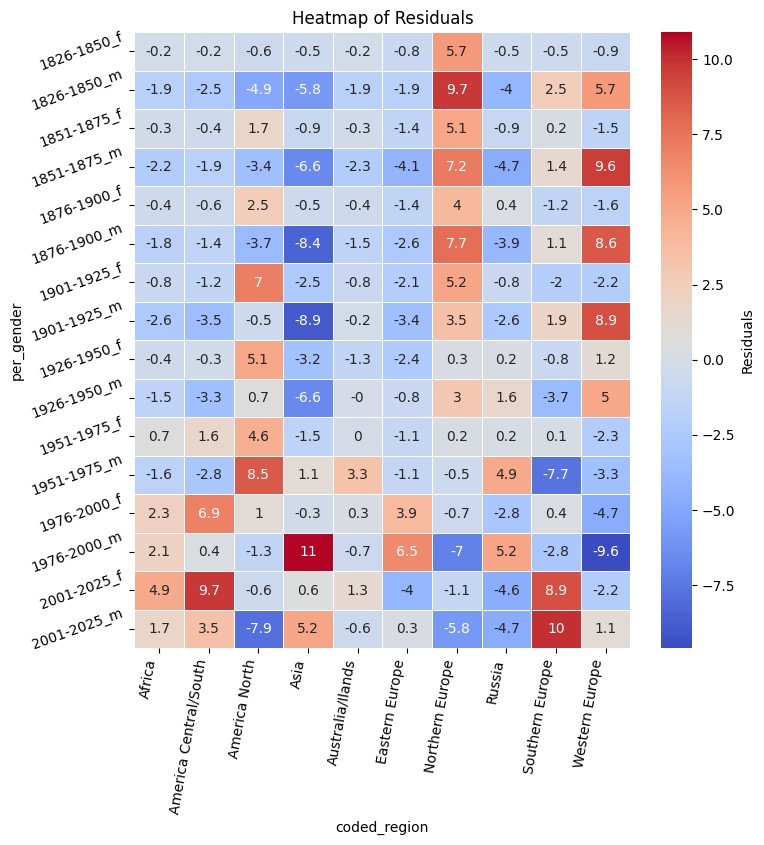

In [64]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

## Possible solution: restrain the table to the more recent values

In [90]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.coded_region, margins=True).iloc[8:, :]
per_gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_gender,,,,,,,,,,,
1926-1950_f,1,3,48,4,0,23,15,17,13,54,178
1926-1950_m,12,22,290,114,19,434,207,217,141,668,2124
1951-1975_f,4,11,73,24,3,61,27,31,30,64,328
1951-1975_m,30,68,813,478,63,947,355,523,260,1080,4617
1976-2000_f,9,32,72,46,5,143,34,26,47,73,487
1976-2000_m,75,143,840,942,55,1679,370,746,540,1342,6732
2001-2025_f,16,45,70,61,8,78,38,19,116,122,573
2001-2025_m,34,87,226,375,23,627,142,190,426,785,2915
All,187,440,2789,2098,192,4543,1685,1954,1930,5528,21346


In [91]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [92]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [93]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_gender,,,,,,,,,,
1926-1950_f,1.8,4.1,24.1,20.3,1.7,39.6,11.8,17.5,15.6,41.5
1926-1950_m,21.4,48.6,287.7,241.8,20.8,472.3,140.5,209.3,186.1,495.5
1951-1975_f,3.3,7.5,44.4,37.3,3.2,72.9,21.7,32.3,28.7,76.5
1951-1975_m,46.5,105.7,625.4,525.6,45.3,1026.6,305.5,454.9,404.5,1077.0
1976-2000_f,4.9,11.1,66.0,55.4,4.8,108.3,32.2,48.0,42.7,113.6
1976-2000_m,67.9,154.1,911.9,766.4,66.0,1496.8,445.5,663.3,589.8,1570.3
2001-2025_f,5.8,13.1,77.6,65.2,5.6,127.4,37.9,56.5,50.2,133.7
2001-2025_m,29.4,66.7,394.9,331.9,28.6,648.1,192.9,287.2,255.4,680.0


If we apply the rule of thumb presented above, we observe that there can be issues with the chi-square test

In [94]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 1141.2574363208903 , dof : 63
p-value : 1.2708765369608591e-197


In [95]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.09529325895962033


Comment: not very significant relationship, only some interesting observations on Southern Europe and Central/Southern America

In [96]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),1))
# std_res.head(2)

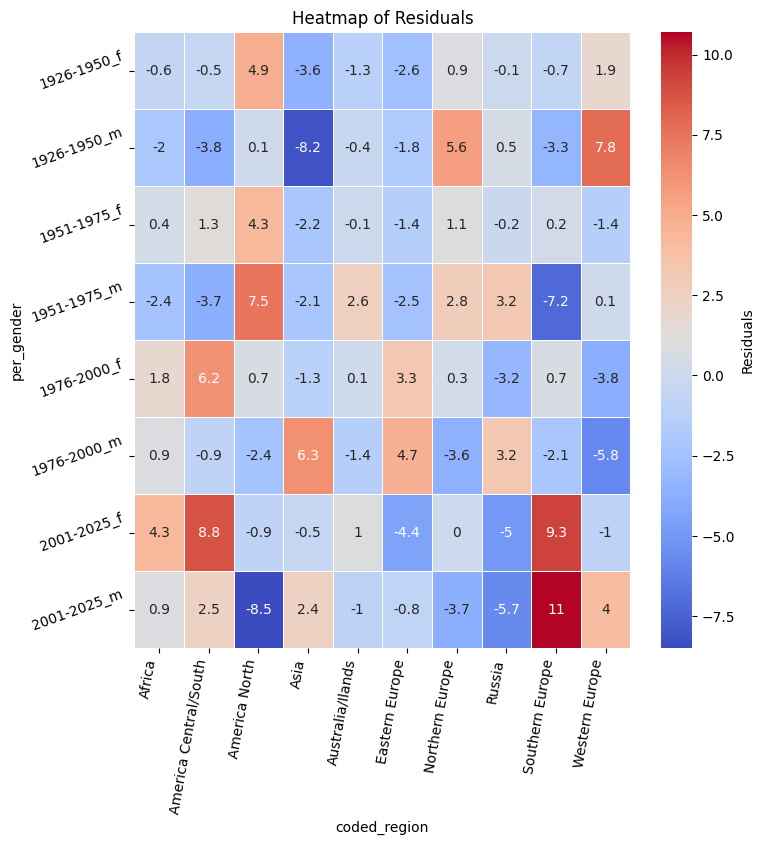

In [97]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

In [100]:
df_pg.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe,Western Europe,1974,1951-1975,1951-1975_m
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe,Northern Europe,1937,1926-1950,1926-1950_m
2,http://www.wikidata.org/entity/Q100153910,Frank J. Blatt,1924,male,Vienna,POINT (16.3725 48.208333),http://www.wikidata.org/entity/Q1741,22,Western Europe,Western Europe,1969,1951-1975,1951-1975_m
3,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,1953,male,Prague,POINT (14.421389 50.0875),http://www.wikidata.org/entity/Q1085,8,Eastern Europe,Eastern Europe,1998,1976-2000,1976-2000_m
4,http://www.wikidata.org/entity/Q100169285,Robert M. Winglee,1958,male,Sydney,POINT (151.21 -33.867778),http://www.wikidata.org/entity/Q3130,2,Australia/New Zealand,Australia/Ilands,2003,2001-2025,2001-2025_m


In [121]:
dfs = df_pg[(df_pg.per_gender.isin(['2001-2025_f']))&(df_pg.coded_region.isin(['Southern Europe', 'America Central/South']))]
print(len(dfs))

161


In [122]:
dfs.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25,per_gender
187,http://www.wikidata.org/entity/Q102283128,Maria Lugaro,1970,female,Turin,POINT (7.676111 45.079167),http://www.wikidata.org/entity/Q495,19,Southern Europe,Southern Europe,2015,2001-2025,2001-2025_f
523,http://www.wikidata.org/entity/Q104717187,Irene Georgakoudi,1971,female,Thessaloniki,POINT (22.935555 40.640278),http://www.wikidata.org/entity/Q17151,19,Southern Europe,Southern Europe,2016,2001-2025,2001-2025_f
629,http://www.wikidata.org/entity/Q105694887,Nuria Martín Chivelet,1966,female,Madrid,POINT (-3.703333 40.416944),http://www.wikidata.org/entity/Q2807,19,Southern Europe,Southern Europe,2011,2001-2025,2001-2025_f
809,http://www.wikidata.org/entity/Q107033568,Violette Impellizzeri,1977,female,Saronno,POINT (9.037 45.6255),http://www.wikidata.org/entity/Q40862,19,Southern Europe,Southern Europe,2022,2001-2025,2001-2025_f
911,http://www.wikidata.org/entity/Q108072966,Lorena Céspedes,1973,female,Santiago,POINT (-70.65 -33.4375),http://www.wikidata.org/entity/Q2887,15,South America,America Central/South,2018,2001-2025,2001-2025_f


In [118]:
dfs[dfs['labelPer'].str.contains('Vaccaro', na=False)]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25,per_gender


In [119]:
df_p[df_p['labelPer'].str.contains('Vaccaro', na=False)]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25
9484,http://www.wikidata.org/entity/Q23727188,Luciana Vaccaro,1969,female,Geneva,POINT (6.15 46.2),http://www.wikidata.org/entity/Q71,22,Western Europe,Western Europe,2014,2001-2025


[Luciana Vaccaro](https://fr.wikipedia.org/wiki/Luciana_Vaccaro) (Wikipedia)